<a href="https://colab.research.google.com/github/Dalton115/MAT-422/blob/main/HW_2_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW2.4   2.4.1 - 2.4.2

* Used Gemini as a study aid and coding partner to clarify probability definitions, debug python code, and format LaTex formulas.
__________________________________________________________________

1. MLE for Random Samples (2.4.1)
2. Linear Regression (2.4.2)

__________________________________________________________________

# MLE for Random Samples(2.4.1)

Key Concept (Explained and given python example):

* MLE is an effective approach for estimating parameters for a given dataset or distribtion by maximizing the likelihood function. In other words, with certain parameters $x_1, x_2, ... x_k$, you can see what parameters make certain distribution most probable.
* For an i.i.d random sample, the joint probability density function is:
$$f(x_1, \dots, x_n; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-(x_1-\mu)^2/(2\sigma^2)} \cdots \frac{1}{\sqrt{2\pi\sigma^2}} e^{-(x_n-\mu)^2/(2\sigma^2)} = \left(\frac{1}{2\pi\sigma^2}\right)^{n/2} e^{-\sum (x_i - \mu)^2 / (2\sigma^2)}$$
* The log likelihood function is:
$$\ln [f(x_1, \dots, x_n; \mu, \sigma^2)] = -\frac{n}{2} \ln (2\pi\sigma^2) - \frac{1}{2\sigma^2} \sum (x_i - \mu)^2$$


* After solving for $\mu$ and taking the partial derivative with respect to $\sigma^2$. Solving for $\sigma^2$ gives the MLE:
$$\hat{\mu} = \bar{X}, \quad \hat{\sigma}^2 = \frac{\sum (X_i - \bar{X})^2}{n}$$


In [ ]:
import numpy as np
from scipy.optimize import minimize

# Step 1: Generate synthetic normal data
np.random.seed(42)
true_mu, true_sigma = 5.0, 2.0
n_samples = 100
data = np.random.normal(loc=true_mu, scale=true_sigma, size=n_samples)

# Step 2: Analytical MLE Calculations (Exact Formulas)
mle_mu_analytical = np.mean(data)
mle_var_analytical = np.var(data, ddof=0)  # ddof=0 divides by n (MLE formula)
mle_sigma_analytical = np.sqrt(mle_var_analytical)

# Step 3: Numerical Optimization via Scipy
def negative_log_likelihood(params, x):
    mu, sigma = params
    if sigma <= 0:
        return np.inf  # Penalty for non-positive standard deviation
    n = len(x)
    log_lh = -0.5 * n * np.log(2 * np.pi * sigma**2) - np.sum((x - mu)**2) / (2 * sigma**2)
    return -log_lh  # Minimize negative log-likelihood = Maximize log-likelihood

# Run numerical optimizer starting from initial guess [0, 1]
initial_guess = [0.0, 1.0]
result = minimize(negative_log_likelihood, initial_guess, args=(data,), method='Nelder-Mead')
mle_mu_num, mle_sigma_num = result.x

# Print comparison
print(f"Analytical  MLE: mu = {mle_mu_analytical:.4f}, sigma^2 = {mle_var_analytical:.4f}")
print(f"Numerical   MLE: mu = {mle_mu_num:.4f}, sigma^2 = {mle_sigma_num**2:.4f}")

Analytical  MLE: mu = 4.7923, sigma^2 = 3.2661
Numerical   MLE: mu = 4.7923, sigma^2 = 3.2661


This code calculates the formulas shown above, and verfies using scipy.
Since the MLE and $\sigma^2$ both line up, we can see the formula is working as expected.

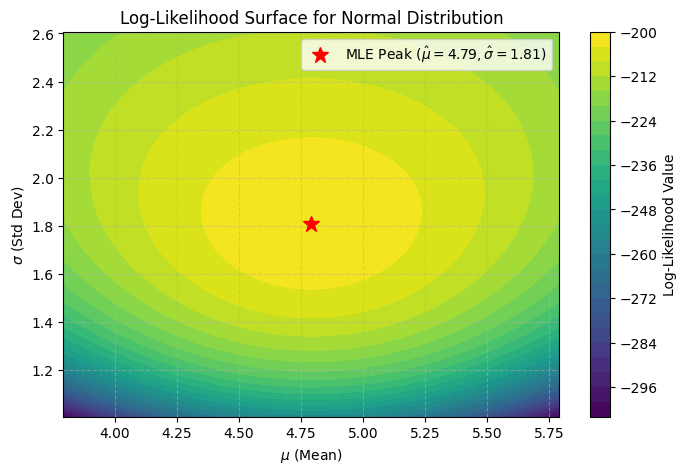

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate grid of potential mu and sigma values
mu_vals = np.linspace(mle_mu_analytical - 1.0, mle_mu_analytical + 1.0, 100)
sigma_vals = np.linspace(mle_sigma_analytical - 0.8, mle_sigma_analytical + 0.8, 100)
MU, SIGMA = np.meshgrid(mu_vals, sigma_vals)

# Evaluate log-likelihood over the grid
Z = np.zeros_like(MU)
for i in range(MU.shape[0]):
    for j in range(MU.shape[1]):
        m, s = MU[i, j], SIGMA[i, j]
        Z[i, j] = -0.5 * n_samples * np.log(2 * np.pi * s**2) - np.sum((data - m)**2) / (2 * s**2)

# Plot contours
plt.figure(figsize=(8, 5))
contour = plt.contourf(MU, SIGMA, Z, levels=30, cmap='viridis')
plt.colorbar(contour, label='Log-Likelihood Value')

# Raw f-string (rf'...') prevents syntax warnings from LaTeX backslashes
plt.plot(mle_mu_analytical, mle_sigma_analytical, 'r*', markersize=12,
         label=rf'MLE Peak ($\hat{{\mu}}={mle_mu_analytical:.2f}, \hat{{\sigma}}={mle_sigma_analytical:.2f}$)')

plt.xlabel(r'$\mu$ (Mean)')
plt.ylabel(r'$\sigma$ (Std Dev)')
plt.title('Log-Likelihood Surface for Normal Distribution')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The snippet above shows a log-likelihood peak using a 2D contour plot. It shows clearly that $(\hat{\mu}, \hat{\sigma})$ is a maximum.

Original Dataset Size: 300
MLE Parameter Estimates: mu_hat = 73.36, sigma_hat = 10.38


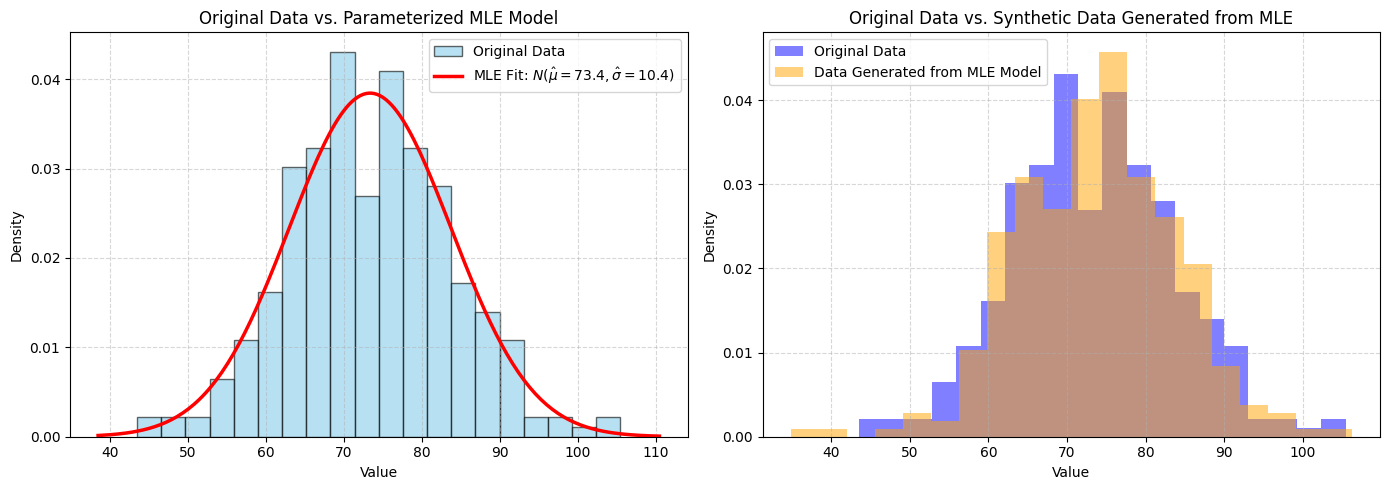

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Step 1: Simulate a "Real-World" Original Dataset (e.g., Student Exam Scores)
np.random.seed(12)
true_mean = 75.0
true_std = 10.0
original_data = np.random.normal(loc=true_mean, scale=true_std, size=300)

# Step 2: Compute Maximum Likelihood Estimates (MLE) from the dataset
mu_hat = np.mean(original_data)
sigma_hat = np.std(original_data, ddof=0)  # ddof=0 uses 'n' for MLE variance

print(f"Original Dataset Size: {len(original_data)}")
print(f"MLE Parameter Estimates: mu_hat = {mu_hat:.2f}, sigma_hat = {sigma_hat:.2f}")

# Step 3: Use MLE parameters to generate NEW synthetic data (Resampling)
generated_data = np.random.normal(loc=mu_hat, scale=sigma_hat, size=300)

# Step 4: Visualize Original Dataset vs. Parameterized Approximation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Original Data Histogram + Fitted MLE Probability Density Curve
x_range = np.linspace(min(original_data) - 5, max(original_data) + 5, 200)
mle_pdf = norm.pdf(x_range, loc=mu_hat, scale=sigma_hat)

axes[0].hist(original_data, bins=20, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Original Data')
axes[0].plot(x_range, mle_pdf, 'r-', linewidth=2.5, label=rf'MLE Fit: $N(\hat{{\mu}}={mu_hat:.1f}, \hat{{\sigma}}={sigma_hat:.1f})$')
axes[0].set_title('Original Data vs. Parameterized MLE Model')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Original Data vs. Data Generated from MLE Model
axes[1].hist(original_data, bins=20, alpha=0.5, color='blue', label='Original Data', density=True)
axes[1].hist(generated_data, bins=20, alpha=0.5, color='orange', label='Data Generated from MLE Model', density=True)
axes[1].set_title('Original Data vs. Synthetic Data Generated from MLE')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Since, as mentioned above the MLE is used to approximate a dataset or distribution, the above python snippet shows the MLE approximation. The MLE is pretty effective at approximating the data and follows its shape closely.

# Linear Regression (2.4.2)

Key Concept (Explained and given python example):


* Linear Regression is used to predict or approximate a numerical value based on data by fitting a linear relationship between independent values and the output.
* We want to find coefficients $\beta_j$ ($j = 0, 1, \dots, p$), to predict $y_i$, using $x_i = (x_{i1}, \dots, x_{ip})$:
$$\hat{y}_i = \beta_0 + \beta_1 x_{i1} + \dots + \beta_p x_{ip}$$
* Eventually we derive the MLE with least squares.

Maximizing $P(\beta \mid y)$ is equivalent to maximizing its logarithm:$$\hat{\beta} = \arg \max_{\beta} \log \left( \prod_{i=1}^n \frac{1}{\sigma \sqrt{2\pi}} \exp\left(-\frac{(y_i - \hat{y}_i)^2}{2\sigma^2}\right) \right)$$$$\hat{\beta} = \arg \max_{\beta} \sum_{i=1}^n \left[ \log \left( \frac{1}{\sigma \sqrt{2\pi}} \right) + \log \left( \exp\left(-\frac{(y_i - \hat{y}_i)^2}{2\sigma^2}\right) \right) \right]$$Dropping terms that do not depend on $\beta$:$$\hat{\beta} = \arg \max_{\beta} \sum_{i=1}^n -\frac{(y_i - \hat{y}_i)^2}{2\sigma^2}$$Flipping the sign converts maximization into minimization:$$\hat{\beta} = \arg \min_{\beta} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$

In [ ]:
import numpy as np
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression

# Step 1: Generate synthetic regression data with Gaussian noise
np.random.seed(42)
n_samples = 100
x = np.random.uniform(0, 10, size=n_samples)

# True parameters: y = beta_0 + beta_1 * x + noise
beta0_true, beta1_true, sigma_true = 3.0, 2.5, 1.5
noise = np.random.normal(loc=0, scale=sigma_true, size=n_samples)
y = beta0_true + beta1_true * x + noise

# Step 2: Analytical OLS Solution (Scikit-Learn)
ols_model = LinearRegression()
ols_model.fit(x.reshape(-1, 1), y)
beta0_ols, beta1_ols = ols_model.intercept_, ols_model.coef_[0]

# Step 3: Numerical MLE Optimization
def neg_log_likelihood(params, x_data, y_data):
    beta0, beta1, sigma = params
    if sigma <= 0:
        return np.inf
    y_hat = beta0 + beta1 * x_data
    # Sum of negative log-likelihood over all points
    log_lh = np.sum(-0.5 * np.log(2 * np.pi * sigma**2) - ((y_data - y_hat)**2) / (2 * sigma**2))
    return -log_lh

# Minimize negative log-likelihood starting from initial guess [0, 0, 1]
initial_guess = [0.0, 0.0, 1.0]
result = minimize(neg_log_likelihood, initial_guess, args=(x, y), method='Nelder-Mead')
beta0_mle, beta1_mle, sigma_mle = result.x

# Compare Results
print(f"OLS Estimates: beta0 = {beta0_ols:.4f}, beta1 = {beta1_ols:.4f}")
print(f"MLE Estimates: beta0 = {beta0_mle:.4f}, beta1 = {beta1_mle:.4f}, sigma = {sigma_mle:.4f}")

OLS Estimates: beta0 = 3.3226, beta1 = 2.4310
MLE Estimates: beta0 = 3.3227, beta1 = 2.4310, sigma = 1.3472


We can verify our math is correct, by checking it with the least squares solution, as the textbook mentions it's exactly the same as the least squares problem. SciKit Learn's linear regression uses OLS. It checks out.

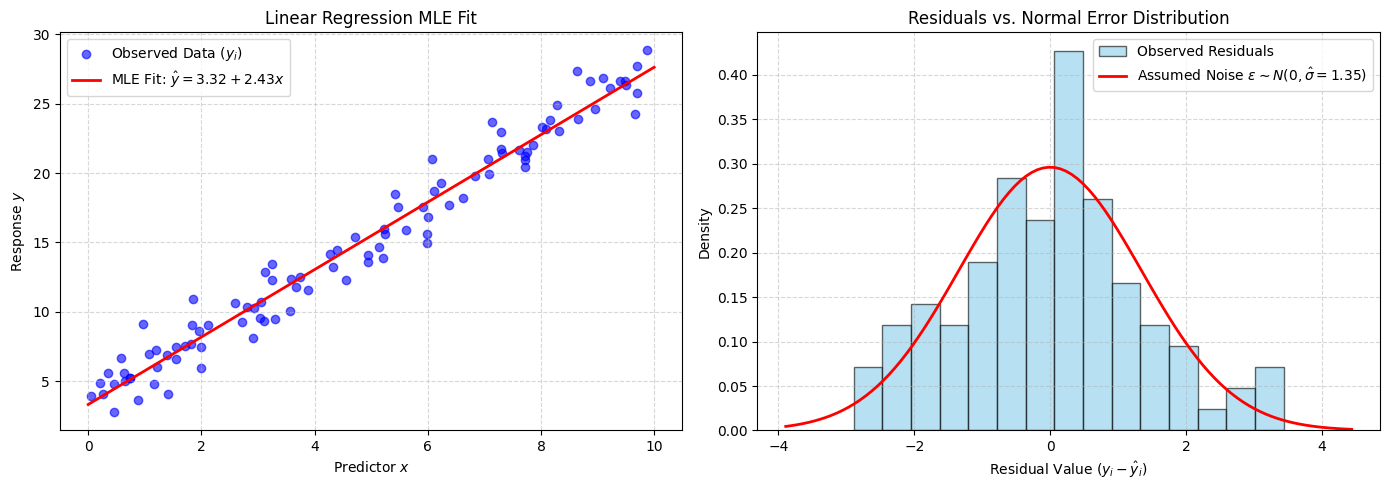

In [ ]:
import matplotlib.pyplot as plt

# Generate grid for fitted line
x_grid = np.linspace(0, 10, 200)
y_hat_grid = beta0_mle + beta1_mle * x_grid

# Generate resampled synthetic data using estimated MLE parameters
y_synthetic = beta0_mle + beta1_mle * x + np.random.normal(0, sigma_mle, size=n_samples)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Observed Data and MLE Fitted Line
axes[0].scatter(x, y, color='blue', alpha=0.6, label=r'Observed Data $(y_i)$')
axes[0].plot(x_grid, y_hat_grid, color='red', linewidth=2,
             label=rf'MLE Fit: $\hat{{y}} = {beta0_mle:.2f} + {beta1_mle:.2f}x$')
axes[0].set_title('Linear Regression MLE Fit')
axes[0].set_xlabel(r'Predictor $x$')
axes[0].set_ylabel(r'Response $y$')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Residual Distribution Verification (Noise ~ N(0, sigma^2))
residuals = y - (beta0_mle + beta1_mle * x)
axes[1].hist(residuals, bins=15, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Observed Residuals')

# Overlaid estimated Gaussian curve N(0, sigma_hat)
r_grid = np.linspace(min(residuals) - 1, max(residuals) + 1, 100)
pdf_residuals = (1 / (sigma_mle * np.sqrt(2 * np.pi))) * np.exp(- (r_grid**2) / (2 * sigma_mle**2))
axes[1].plot(r_grid, pdf_residuals, 'r-', linewidth=2,
             label=rf'Assumed Noise $\varepsilon \sim N(0, \hat{{\sigma}}={sigma_mle:.2f})$')
axes[1].set_title('Residuals vs. Normal Error Distribution')
axes[1].set_xlabel(r'Residual Value $(y_i - \hat{y}_i)$')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Here we plot a linear regression and see it is closely related to the trend of the data. The second plot shows the error (distance between the red linear regression line and the blue dots which are the real data). The erorr is normally distributed, which  is the red curve.

# Checklist


*   Read, checked, and personalized each example. Also extended at least one example. They run without errors.
*   Covered key concepts from the textbook and illustrated them in python.
*   Explanations written in my own words accompany each example.
*   Saved directly from collab to github.
*   Carefully formatted, code is explained in comments, and it follows the given order from the textbook and in the canvas assignments